# Exercise: Run the Matrix Multiplication Benchmark

In this task, you will benchmark three matrix multiplication implementations from three different libraries, `NumPy`, `TensorFlow`, and `PyTorch`.

Below are the tasks to be completed in code:
- Using the same input and the same hardware setting, compare their runtime and memory behaviour
- Report the measured time and memory changes
- Visualize the results in plots

Additionally, discuss the following points in written form, in a markdown cell:
- State the time and space complexity of your benchmarking approach, excluding the plotting part
- Explain the reasoning behind your choices for time and memory measurement methods

The three matrix multiplication implementations to compare are:
1. NumPy: `np.dot`
2. TensorFlow: `tf.matmul` 
3. PyTorch: `torch.matmul`

Use the default settings below to reproduce the experiment exactly:
- **Matrix size:** 2000 × 2000, with randomly generated values
- **Hardware:** CPU only

# Solution

## Time and Memory Tracking Setup

In [41]:
import time
import statistics
import threading
import os
import psutil


process = psutil.Process(os.getpid())


def benchmark(func, *args, repeats=7, warmup=1, sample_interval=0.001, **kwargs):
    for _ in range(warmup):
        func(*args, **kwargs)

    times_ms = []
    peak_mem_kb = []

    for _ in range(repeats):
        # measure RSS before the function call
        baseline_rss = process.memory_info().rss
        peak_rss = baseline_rss
        stop_flag = False

        # Tracking memory in a separate thread:
        def monitor_memory():
            nonlocal peak_rss, stop_flag
            while not stop_flag:
                rss = process.memory_info().rss
                # track the peak RSS during the call
                if rss > peak_rss:
                    peak_rss = rss
                time.sleep(sample_interval)

        monitor_thread = threading.Thread(target=monitor_memory)
        monitor_thread.start()

        # Tracking time:
        t0 = time.perf_counter()
        func(*args, **kwargs)
        t1 = time.perf_counter()

        stop_flag = True
        monitor_thread.join()

        times_ms.append((t1 - t0) * 1000)
        # compute peak − baseline = how much additional memory this operation needed
        #       and convert to KB
        peak_mem_kb.append((peak_rss - baseline_rss) / 1024)

    # Return median time and median peak memory increase across all repeats
    return {
        "median_ms": statistics.median(times_ms),
        "median_peak_kb": statistics.median(peak_mem_kb),
    }

## Benchmarking Setup and Call

In [42]:
import numpy as np
import tensorflow as tf
import torch


def benchmark_matmul(N, repeats=3, warmup=2):
    a_np = np.random.rand(N, N)
    b_np = np.random.rand(N, N)

    a_tf = tf.constant(a_np)
    b_tf = tf.constant(b_np)

    a_torch = torch.tensor(a_np)
    b_torch = torch.tensor(b_np)

    results = {
        "NumPy": benchmark(np.dot, a_np, b_np, repeats=repeats, warmup=warmup),
        "TensorFlow": benchmark(tf.matmul, a_tf, b_tf, repeats=repeats, warmup=warmup),
        "PyTorch": benchmark(
            torch.matmul, a_torch, b_torch, repeats=repeats, warmup=warmup
        ),
    }

    return results

## Reading Results

In [43]:
results = benchmark_matmul(N=2000, repeats=20)

for lib_name, res in results.items():
    print(
        f"{lib_name}: median time = {res['median_ms']:.2f} ms, "
        f"median peak memory increase = {res['median_peak_kb']:.2f} KB"
    )

NumPy: median time = 34.61 ms, median peak memory increase = 16.00 KB
TensorFlow: median time = 82.35 ms, median peak memory increase = 24.00 KB
PyTorch: median time = 32.37 ms, median peak memory increase = 16.00 KB


## Plotting

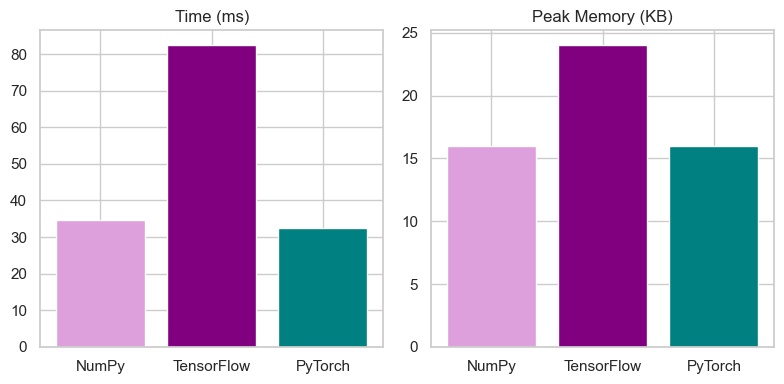

In [51]:
import matplotlib.pyplot as plt

labels = list(results.keys())
times = [results[k]["median_ms"] for k in labels]
memory = [results[k]["median_peak_kb"] for k in labels]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.bar(labels, times, color=["plum", "purple", "teal"])
plt.title("Time (ms)")

plt.subplot(1, 2, 2)
plt.bar(labels, memory, color=["plum", "purple", "teal"])
plt.title("Peak Memory (KB)")

plt.tight_layout()
plt.show()

## Discussion

### Time & Memory Complexity

| _Complexity_      | Matrix - Multiplication |
|-------------------|-------------------------|
| Time Complexity   | $O(n^3)$                |
| Memory Complexity | $O(n^2)$                |

Because it is the most costly one in this benchmarking, the complexities are equal to the time&memory cost of one matrix multiplication.

### Methods for Time & Memory Tracking

#### Why `psutil`?

For this task, `psutil` is a better choice than `tracemalloc` since
`tracemalloc` captures Python managed allocations and do not fully reflect memory used internally by NumPy, TensorFlow, and PyTorch _(in which a good proportion of that is allocated in C or C++ layers)_.

#### Why `time.perf_counter()`?

`time.perf_counter()` is used because it offers high resolution timing and is not affected by system clock changes, making it reliable for benchmarking.